# JURNAL FIX MODUL 3
### NAMA : MUHAMMAD IZZUL ISLAM
### NIM : F1D02410077

In [36]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Kode di atas mengimpor tiga library utama, yaitu **`cv2` (OpenCV)** untuk pemrosesan gambar dan computer vision, **`matplotlib.pyplot`** untuk menampilkan gambar atau grafik, dan **`numpy`** untuk operasi array dan matriks numerik.

Kode di bawah membaca gambar backup.jpg menggunakan OpenCV lalu mengonversinya ke grayscale dengan cv.cvtColor, kemudian menampilkan hasil gambar grayscale tersebut menggunakan plt.imshow dengan colormap gray.

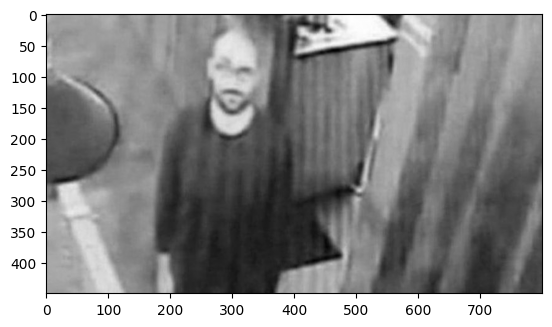

In [37]:
cctv = cv.imread('backup.jpg')
cctvGray = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)

plt.imshow(cctvGray, cmap = 'gray')

In [38]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += val
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()
                    n = len(values)
                    mid = n // 2
                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2
                    canvas[i, j] = median_val
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

Kode di atas mendefinisikan fungsi filter untuk menerapkan tiga jenis filter pada gambar grayscale, yaitu mean (rata-rata nilai piksel dalam region), median (nilai tengah setelah diurutkan), dan modus (nilai yang paling sering muncul). Fungsi ini bekerja dengan menambahkan padding pada gambar menggunakan np.pad, lalu menggeser jendela (window) berukuran size x size pada setiap piksel untuk mengambil region sekitarnya dan menghitung nilai baru yang disimpan ke dalam canvas sebagai output gambar hasil filtering.

In [39]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
[1/10, 1/10, 1/10],
[1/10, 1/5, 1/10],
[1/10, 1/10, 1/10]
])
# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
[1/9, 1/9, 1/9],
[1/9, 8/9, 1/9],
[1/9, 1/9, 1/9]
])
 # kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
 # kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)
# kernel roberts sumbu x / x-axis sobel kernel
robertsX = np.array([
[1, 0],
[0, -1]
], dtype=np.float32)
# kernel roberts sumbu y / y-axis sobel kernel
robertsY = np.array([
[0, 1],
[-1, 0]
], dtype=np.float32)

Kode di atas mendefinisikan berbagai kernel yang digunakan dalam operasi konvolusi pada gambar. **`kernelSmoothing`** dan **`kernelSharpening`** masing-masing digunakan untuk menghaluskan dan mempertajam gambar. Selain itu, terdapat kernel deteksi tepi untuk tiga metode berbeda, yaitu **Sobel** (sumbu X dan Y), **Prewitt** (sumbu X dan Y), dan **Roberts** (sumbu X dan Y), di mana kernel sumbu X mendeteksi tepi horizontal dan kernel sumbu Y mendeteksi tepi vertikal.

In [40]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Kode di atas mendefinisikan fungsi `convolution` yang melakukan operasi konvolusi antara gambar dan kernel secara manual. Fungsi ini menambahkan padding berisi nol pada gambar menggunakan `np.pad`, lalu menggeser kernel pada setiap piksel untuk mengalikan elemen-elemen region dengan kernel dan menjumlahkan hasilnya menggunakan `np.sum`, yang kemudian disimpan ke dalam `canvas` sebagai output bertipe `float32`.

In [41]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Kode di atas mendefinisikan fungsi `edge` untuk mendeteksi tepi pada gambar dengan menghitung gradien horizontal (`gx`) dan vertikal (`gy`) menggunakan fungsi `convolution`, lalu menggabungkan keduanya dengan menjumlahkan nilai absolutnya. Hasilnya kemudian dinormalisasi ke rentang 0–255 dan dipotong menggunakan `np.clip` agar tetap dalam batas valid sebelum dikembalikan sebagai gambar bertipe `uint8`.

In [42]:
smoothcctv = convolution(cctvGray, kernelSmoothing)
sharpcctv = convolution(cctvGray, kernelSharpening)
smoothSharpcctv = convolution(cctvGray, kernelSmoothing)
smoothSharpcctvm = convolution(smoothSharpcctv, kernelSharpening)

Kode di atas menerapkan fungsi `convolution` pada gambar grayscale `cctvGray` dengan beberapa kombinasi kernel, yaitu **smoothing** saja, **sharpening** saja, serta **smoothing dilanjutkan sharpening** secara bertahap, di mana hasil smoothing (`smoothSharpcctv`) digunakan sebagai input untuk proses sharpening berikutnya (`smoothSharpcctvm`).

Kode di bawah menampilkan tiga gambar hasil konvolusi secara berdampingan menggunakan `plt.subplot` dalam satu figure berukuran 12x6, yaitu hasil **Smoothing**, **Sharpening**, dan **Smoothing + Sharpening**, dengan sumbu dinonaktifkan menggunakan `plt.axis('off')` agar tampilan lebih bersih.

- Smoothing (Penghalusan)
Menggunakan kernel yang merata-ratakan nilai piksel di sekitarnya sehingga menghasilkan gambar yang lebih halus dan buram (blur). Berguna untuk mengurangi noise sebelum proses selanjutnya, namun jika digunakan sendiri akan membuat detail dan tepi gambar menjadi kurang tajam.
- Sharpening (Penajaman)
Menggunakan kernel yang memperkuat perbedaan antar piksel sehingga menghasilkan gambar dengan tepi dan detail yang lebih tajam dan jelas. Namun jika digunakan langsung tanpa smoothing terlebih dahulu, noise pada gambar juga ikut diperkuat sehingga gambar bisa terlihat lebih kasar.
- Smoothing + Sharpening (Kombinasi)
Menggabungkan keduanya secara bertahap, yaitu smoothing dilakukan terlebih dahulu untuk mengurangi noise, kemudian dilanjutkan sharpening untuk mempertegas detail dan tepi yang tersisa. Kombinasi ini menghasilkan gambar yang lebih bersih sekaligus tajam dibandingkan menggunakan salah satu metode saja, karena noise sudah ditekan sebelum proses penajaman dilakukan.

Perbedaan Filter Mean, Median, dan Modus
- Mean (Rata-rata) bekerja dengan menjumlahkan semua nilai piksel dalam region lalu membaginya dengan jumlah piksel, sehingga menghasilkan gambar yang lebih halus dan mengurangi noise acak, namun kelemahannya adalah sensitif terhadap nilai ekstrem sehingga tepi gambar cenderung menjadi buram karena semua piksel diperlakukan sama.
- Median (Nilai Tengah) bekerja dengan mengurutkan semua nilai piksel dalam region lalu mengambil nilai tengahnya, sehingga sangat efektif menghilangkan salt-and-pepper noise karena nilai ekstrem tidak ikut dihitung, dan lebih baik dari mean dalam mempertahankan ketajaman tepi gambar.
- Modus (Nilai Terbanyak) bekerja dengan mengambil nilai piksel yang paling sering muncul dalam region, sehingga cocok untuk gambar dengan area warna seragam, namun kurang efektif pada gambar dengan gradasi warna kompleks karena dapat menghasilkan efek posterisasi di mana warna terlihat bertingkat dan tidak halus.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

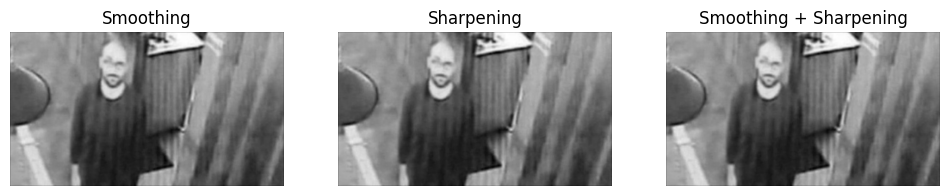

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(smoothcctv, cmap = 'gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(smoothcctv, cmap = 'gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothSharpcctv, cmap = 'gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

In [44]:
prewitt = edge(smoothSharpcctv, prewittX, prewittY)
sobel = edge(smoothSharpcctv, sobelX, sobelY)
roberts = edge(smoothSharpcctv, robertsX, robertsY)
prewittSobel = (prewitt + sobel) / 2
prewittRoberts = (prewitt + roberts) /2
sobelRoberts = (sobel + roberts) / 2
prewittSobelRoberts = (prewitt + sobel + roberts) / 3 

Kode di atas menerapkan fungsi edge pada gambar smoothSharpcctv menggunakan tiga metode deteksi tepi, yaitu Prewitt, Sobel, dan Roberts, kemudian mengombinasikannya secara berpasangan maupun ketiganya sekaligus dengan cara merata-ratakan hasilnya untuk menghasilkan deteksi tepi yang lebih komprehensif.

Kode di bawah menampilkan tujuh gambar hasil deteksi tepi secara berdampingan dalam grid 2x4 menggunakan `plt.subplot` pada figure berukuran 16x8, mencakup hasil masing-masing metode (**Prewitt**, **Sobel**, **Roberts**) serta kombinasinya (**Prewitt+Sobel**, **Prewitt+Roberts**, **Sobel+Roberts**, **Prewitt+Sobel+Roberts**), dengan sumbu dinonaktifkan untuk tampilan yang lebih bersih.

Kegunaan Operator dan Kombinasinya
- Prewitt mendeteksi tepi dengan menghitung gradien pada sumbu X dan Y menggunakan bobot yang seragam pada setiap arah, sehingga cocok untuk mendeteksi tepi secara umum namun kurang sensitif terhadap tepi yang halus karena tidak memberikan bobot lebih pada piksel pusat.
- Sobel bekerja serupa dengan Prewitt namun memberikan bobot lebih besar pada piksel yang berdekatan dengan pusat kernel, sehingga lebih sensitif terhadap tepi dan lebih tahan terhadap noise dibandingkan Prewitt, menjadikannya operator deteksi tepi yang paling umum digunakan.
- Roberts menggunakan kernel 2x2 yang menghitung gradien secara diagonal, sehingga menghasilkan deteksi tepi yang lebih tajam dan responsif namun lebih rentan terhadap noise karena ukuran kernelnya yang kecil dan tidak mempertimbangkan banyak piksel sekitar.
- Prewitt + Sobel menggabungkan kekuatan deteksi tepi horizontal-vertikal dari keduanya sehingga menghasilkan tepi yang lebih lengkap dan konsisten, karena sensitivitas Sobel yang lebih tinggi dikombinasikan dengan keseragaman Prewitt saling melengkapi satu sama lain.
- Prewitt + Roberts menggabungkan deteksi tepi horizontal-vertikal dari Prewitt dengan deteksi tepi diagonal dari Roberts, sehingga tepi yang terdeteksi menjadi lebih menyeluruh mencakup berbagai arah, meskipun kombinasi ini lebih rentan terhadap noise akibat karakteristik Roberts.
- Sobel + Roberts menggabungkan sensitivitas tinggi Sobel dengan kemampuan deteksi diagonal Roberts, menghasilkan tepi yang lebih detail dan tajam pada berbagai arah, namun tetap perlu diwaspadai pengaruh noise dari kernel Roberts yang kecil.
- Prewitt + Sobel + Roberts merupakan kombinasi ketiga operator sekaligus yang menghasilkan deteksi tepi paling menyeluruh karena mencakup deteksi horizontal, vertikal, maupun diagonal dari berbagai tingkat sensitivitas, sehingga tepi yang dihasilkan lebih lengkap meskipun noise juga berpotensi lebih tinggi dibandingkan kombinasi dua operator.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

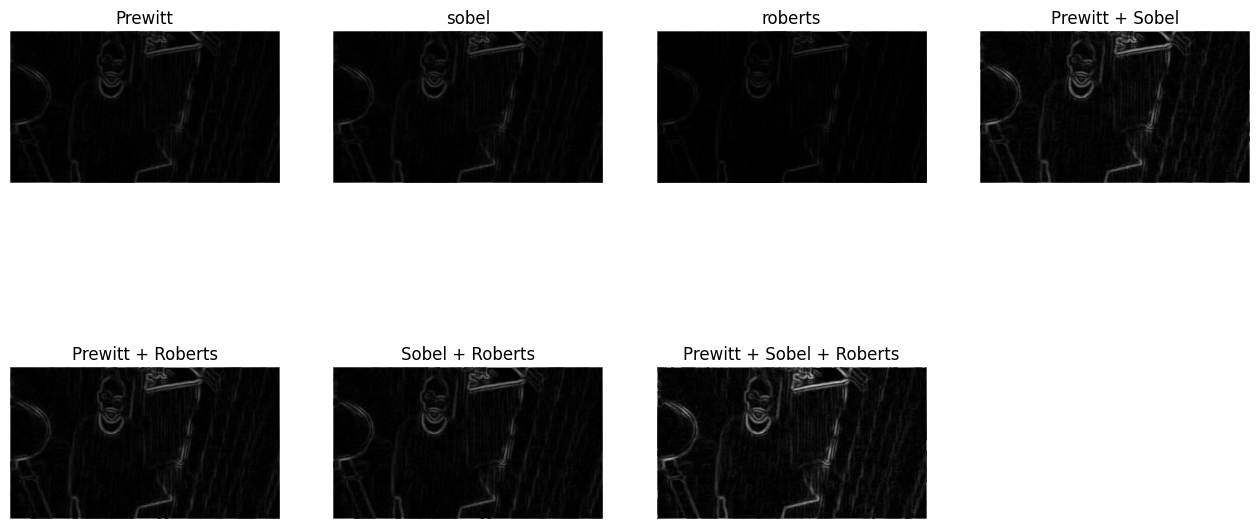

In [45]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(prewitt, cmap = 'gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobel, cmap = 'gray')
plt.title('sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap = 'gray')
plt.title('roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewittSobel, cmap = 'gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewittRoberts, cmap = 'gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobelRoberts, cmap = 'gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(prewittSobelRoberts, cmap = 'gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

In [46]:
def thresholding (image, threshold):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] > threshold:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0
    return hasil

Kode di atas mendefinisikan fungsi `thresholding` yang mengubah gambar grayscale menjadi gambar biner dengan membandingkan setiap nilai piksel terhadap nilai `threshold`, di mana piksel yang nilainya lebih besar dari threshold akan diset menjadi **255** (putih) dan sisanya menjadi **0** (hitam).

In [47]:
thresTepi10 = thresholding(prewittSobel, 10)
thresTepi20 = thresholding(prewittSobel, 20)
thresTepi30 = thresholding(prewittSobel, 30)
thresTepi40 = thresholding(prewittSobel, 40)
thresTepi50 = thresholding(prewittSobel, 50)
thresTepi60 = thresholding(prewittSobel, 60)

Kode di atas menerapkan fungsi `thresholding` pada gambar hasil deteksi tepi `prewittSobel` dengan enam nilai threshold yang berbeda (10, 20, 30, 40, 50, 60) untuk menghasilkan gambar biner dengan tingkat sensitivitas tepi yang bervariasi, di mana semakin besar nilai threshold maka semakin sedikit tepi yang terdeteksi.

Kode di bawah menampilkan enam gambar hasil thresholding secara berdampingan dalam grid 2x3 menggunakan `plt.subplot` pada figure berukuran 15x5, mencakup hasil threshold dengan nilai **10, 20, 30, 40, 50, dan 60**, dengan sumbu dinonaktifkan untuk tampilan yang lebih bersih.

Pengaruh Threshold secara Umum adalah mengubah gambar hasil deteksi tepi menjadi gambar biner hitam-putih dengan cara memisahkan piksel yang dianggap sebagai tepi (255/putih) dan bukan tepi (0/hitam) berdasarkan nilai batasnya, sehingga semakin tepat nilai threshold yang dipilih maka semakin akurat tepi yang terdeteksi.
- Threshold Rendah (10–20) menghasilkan gambar dengan tepi yang sangat banyak dan rapat karena hampir semua piksel yang memiliki perubahan nilai sekecil apapun akan dianggap sebagai tepi, akibatnya gambar terlihat penuh dengan garis-garis tipis yang tidak hanya menangkap tepi objek utama tetapi juga noise dan tekstur kecil yang tidak relevan sehingga objek menjadi sulit dibedakan.
- Threshold Tinggi (50–60) menghasilkan gambar dengan tepi yang sangat sedikit karena hanya piksel dengan perubahan nilai yang sangat besar yang dianggap sebagai tepi, akibatnya banyak detail tepi yang hilang dan gambar terlihat terlalu bersih hingga kontur objek utama pun bisa ikut terpotong sehingga bentuk objek menjadi tidak utuh.
- Nilai Threshold Terbaik untuk kasus ini adalah 30, karena pada nilai tersebut tepi yang dihasilkan cukup bersih dari noise namun tetap mempertahankan kontur utama objek secara menyeluruh. Threshold 30 berada di titik keseimbangan antara threshold rendah yang terlalu banyak menangkap noise dan threshold tinggi yang terlalu banyak membuang detail tepi, sehingga hasil deteksi tepi lebih representatif dan mudah dianalisis lebih lanjut.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

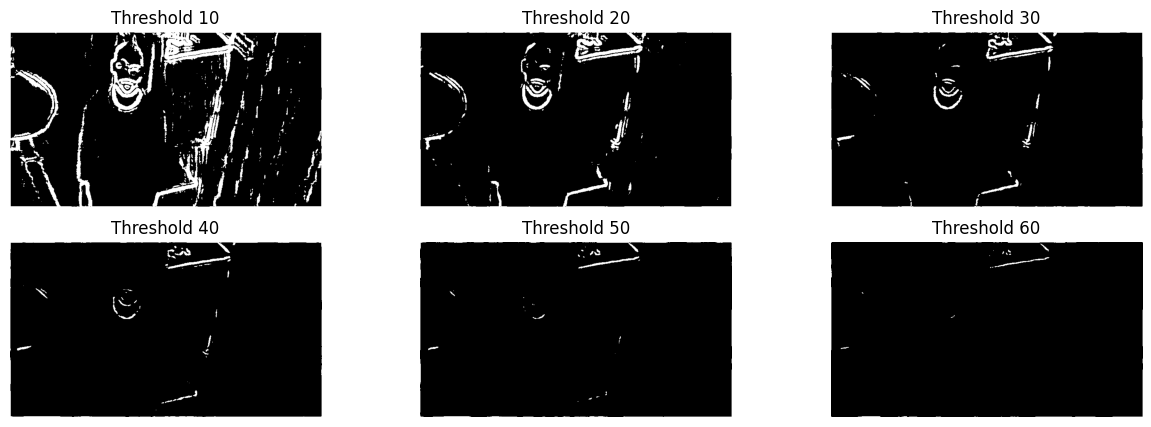

In [48]:
plt.figure(figsize=(15, 5))

plt.subplot(2, 3, 1)
plt.imshow(thresTepi10, cmap = 'gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(thresTepi20, cmap = 'gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(thresTepi30, cmap = 'gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(thresTepi40, cmap = 'gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(thresTepi50, cmap = 'gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(thresTepi60, cmap = 'gray')
plt.title('Threshold 60')
plt.axis('off')

In [49]:
h, w = smoothSharpcctv.shape
y_start, y_end = 35, 449 
x_start, x_end = 150, 400

masker = np.zeros((h, w))
maskerTepi = np.zeros((h, w))

for i in range(y_start, y_end):
    for j in range(x_start, x_end):
        masker[i, j] = 255

for i in range(y_start, y_end + 1):
    for j in range(x_start, x_end + 1):
        if i == y_start or i == y_end or j == x_start or j == x_end:
            maskerTepi[i, j] = 255

Kode di atas membuat dua masker berbentuk persegi panjang pada area yang ditentukan oleh koordinat `y_start`, `y_end`, `x_start`, dan `x_end`. **`masker`** mengisi seluruh area dalam koordinat tersebut dengan nilai 255 (putih penuh), sedangkan **`maskerTepi`** hanya mengisi bagian tepi/batas persegi panjang saja dengan nilai 255, sehingga menghasilkan bentuk seperti kotak kosong.

Kode di bawah menampilkan dua gambar masker secara terpisah menggunakan `plt.imshow`, yaitu **`masker`** yang menampilkan area persegi panjang penuh dan **`maskerTepi`** yang menampilkan hanya garis tepi persegi panjang, keduanya ditampilkan dalam colormap `gray`.

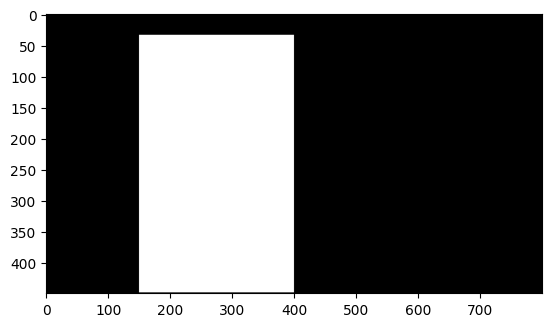

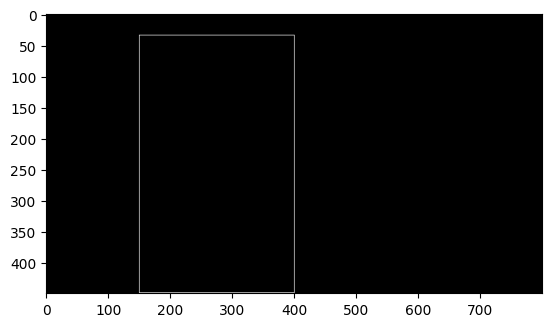

In [50]:
plt.imshow(masker, cmap = 'gray')
plt.show()

plt.imshow(maskerTepi, cmap = 'gray')
plt.show()

In [51]:
cctvBaru = cv.imread('backup.jpg') 
cctvRGB = cv.cvtColor(cctvBaru, cv.COLOR_BGR2RGB)
cctvKuning = cctvRGB.copy()

Kode di atas membaca ulang gambar `backup.jpg` menggunakan OpenCV, mengonversinya dari format BGR ke RGB dengan `cv.cvtColor` agar warna tampil dengan benar, lalu membuat salinan gambar tersebut sebagai `cctvKuning` yang akan digunakan untuk manipulasi warna selanjutnya.

Kode di bawah memberikan efek warna kuning pada area yang ditentukan oleh `masker` dengan mencampurkan nilai channel merah (R) dan hijau (G) sebesar 50% dengan nilai 255, lalu menampilkan tiga gambar secara berdampingan dalam grid 1x3, yaitu **`masker`** penuh, **`maskerTepi`** garis tepi, dan **`cctvKuning`** hasil pewarnaan kuning pada area yang dimasker.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

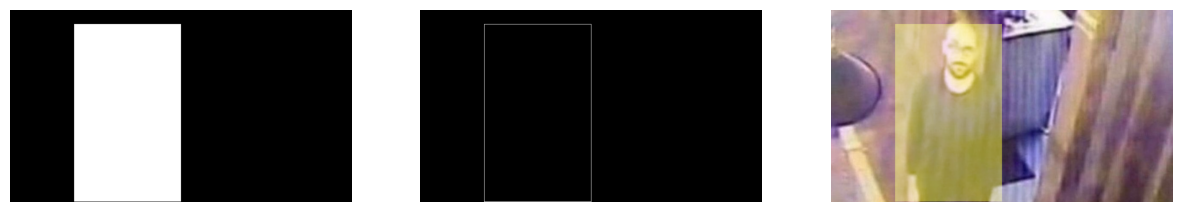

In [52]:
for i in range(h):
    for j in range(w):
        if masker[i, j] == 255:
            cctvKuning[i, j, 0] = (cctvKuning[i, j, 0] * 0.5 + 255 * 0.5)
            cctvKuning[i, j, 1] = (cctvKuning[i, j, 1] * 0.5 + 255 * 0.5)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(masker, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(maskerTepi, cmap = 'gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cctvKuning)
plt.axis('off')

In [53]:
david = cv.imread('david.jpg')

Kode di atas membaca gambar `david.jpg` dari direktori kerja menggunakan OpenCV dan menyimpannya ke dalam variabel `david`.

Kode di bawah menampilkan gambar `david` dalam figure berukuran 10x10 menggunakan `plt.imshow` dengan colormap `gray`.

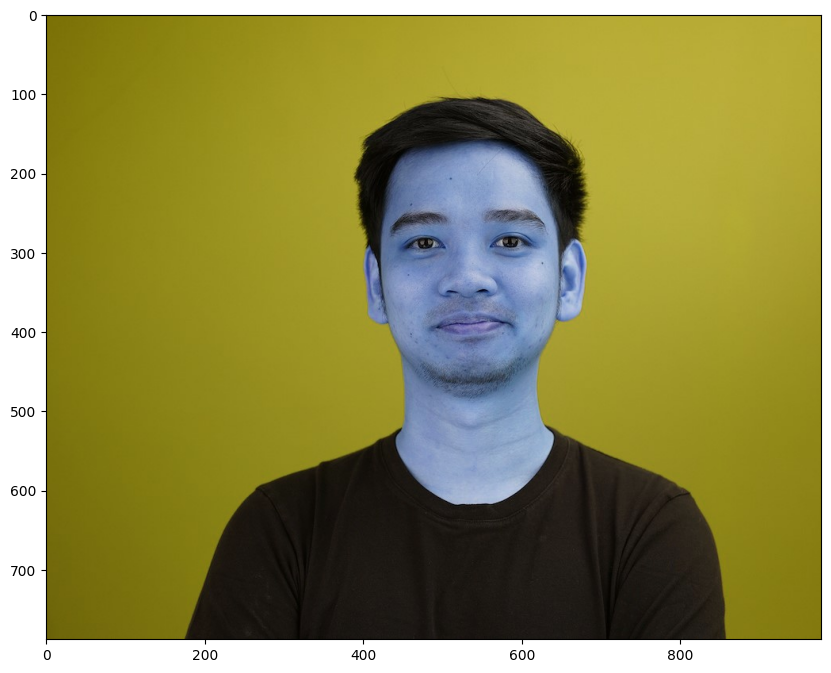

In [54]:
plt.figure(figsize=(10, 10))
plt.imshow(david, cmap = 'gray')
plt.show()

Kode di bawah mengonversi gambar `david` dari format BGR ke grayscale menggunakan `cv.cvtColor`, lalu menampilkan hasilnya dalam figure berukuran 10x10 dengan judul **'David Gray'** menggunakan colormap `gray`.

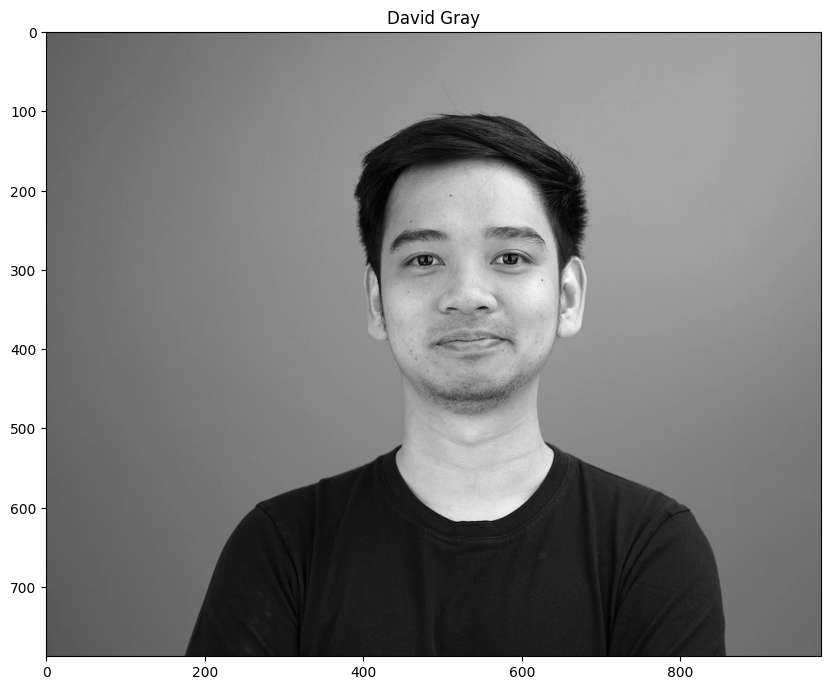

In [55]:
davidGray = cv.cvtColor(david, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))
plt.title('David Gray')
plt.imshow(davidGray, cmap = 'gray')
plt.show()

Kode di bawah mengonversi gambar `david` dari format BGR ke RGB menggunakan `cv.cvtColor`, lalu menampilkan hasilnya dalam figure berukuran 10x10 dengan judul **'David RGB'** menggunakan `plt.imshow`.

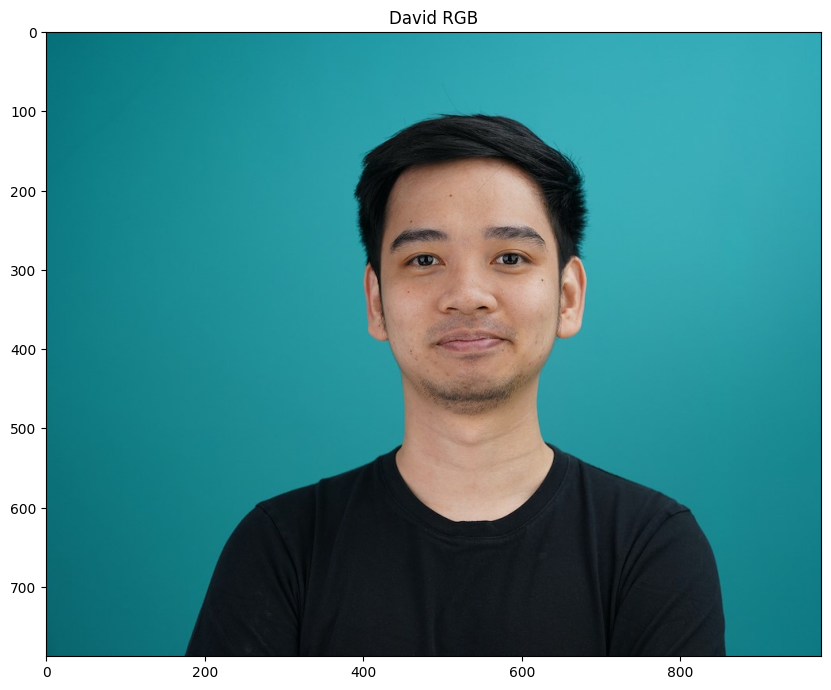

In [56]:
davidRGB = cv.cvtColor(david, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.title('David RGB')
plt.imshow(davidRGB, cmap = 'gray')
plt.show()

Kode di bawah menerapkan deteksi tepi pada gambar `davidGray` menggunakan metode **Sobel** dengan fungsi `edge`, lalu menampilkan hasilnya dalam figure berukuran 10x10 dengan colormap `gray`.

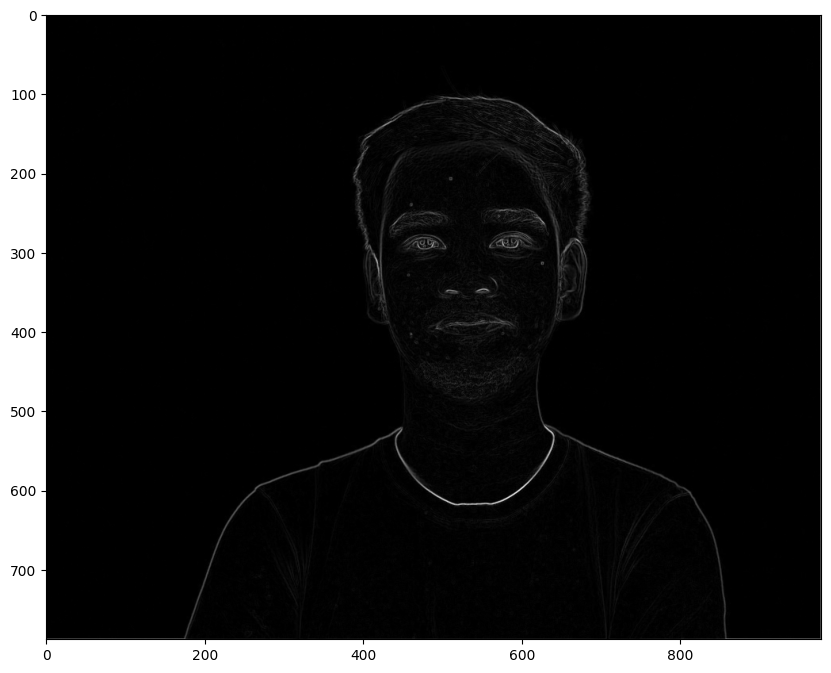

In [57]:
davidTepi = edge(davidGray, sobelX, sobelY)

plt.figure(figsize=(10, 10))
plt.imshow(davidTepi, cmap = 'gray')

In [58]:
h, w = davidGray.shape
DavidMask = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        r = float(davidRGB[i, j, 0])
        g = float(davidRGB[i, j, 1])
        b = float(davidRGB[i, j, 2])
        if g > r and b > r and g > 80 and b > 80:
            DavidMask[i, j] = 0
        else:
            DavidMask[i, j] = 255

Kode di atas membuat masker biner `DavidMask` dengan mengiterasi setiap piksel pada gambar `davidRGB`, di mana piksel yang memiliki nilai channel hijau (G) dan biru (B) lebih dominan dari merah (R) serta keduanya di atas nilai 80 akan diset menjadi **0** (hitam/latar belakang), sedangkan piksel lainnya diset menjadi **255** (putih/objek), sehingga efektif memisahkan objek dari latar belakang berwarna kebiruan.

Kode di bawah menghaluskan masker `DavidMask` menggunakan filter **median** berukuran 9x9 untuk mengurangi noise dan merapikan area masker, lalu menampilkan hasilnya dalam figure berukuran 10x10 dengan colormap `gray`.

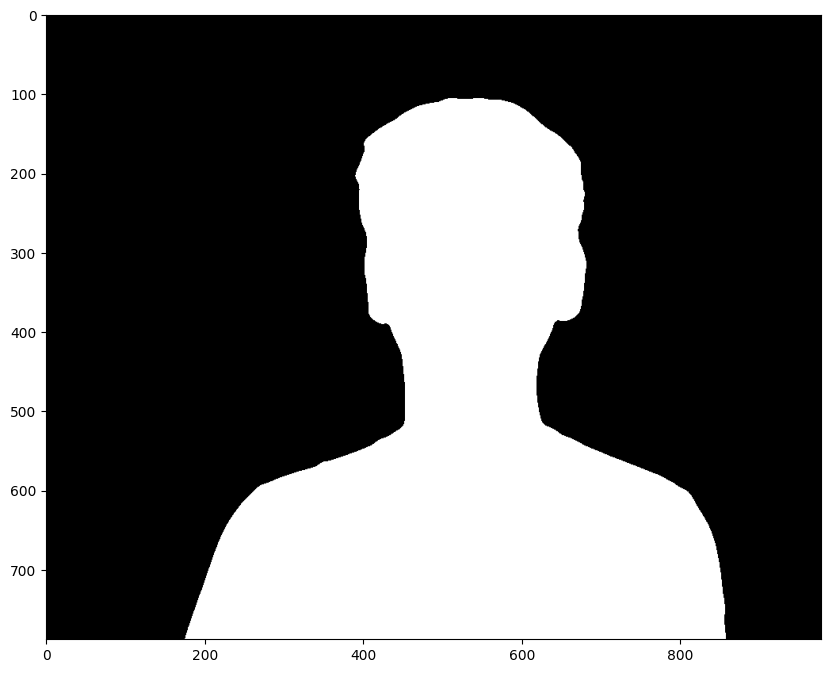

In [59]:
DavidMask = filter(DavidMask, 9, 'median')

plt.figure(figsize=(10, 10))
plt.imshow(DavidMask, cmap = 'gray')

Kode di bawah membuat gambar baru `davidNoBG` berukuran sama dengan gambar asli namun dengan latar belakang dihilangkan, di mana piksel yang bernilai 255 pada `DavidMask` akan diisi dengan warna asli dari `davidRGB`, sedangkan piksel lainnya diisi dengan warna putih (255), lalu hasilnya ditampilkan dalam figure berukuran 10x10.

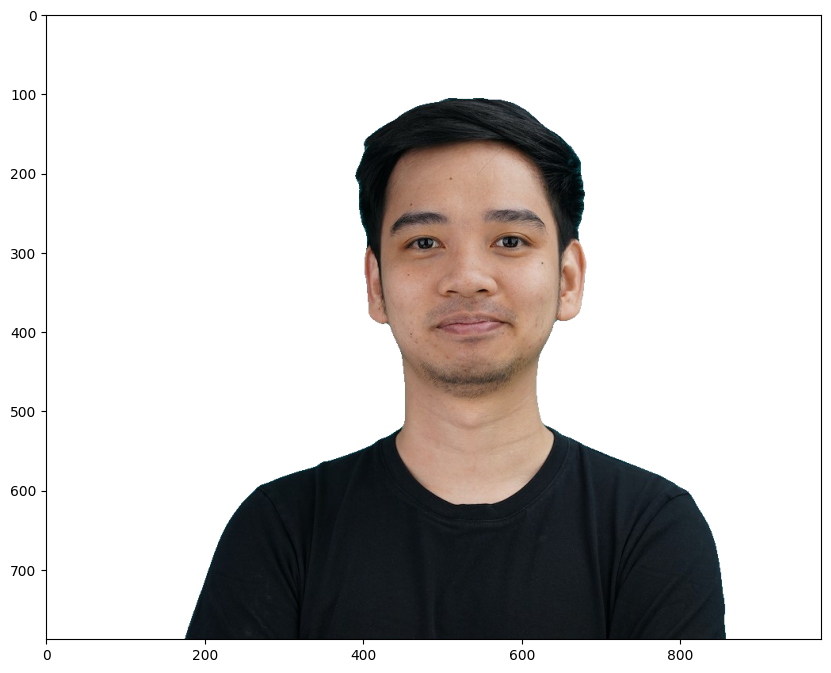

In [60]:
davidNoBG = np.zeros((h, w, 3), dtype=np.uint8)
for i in range (h):
    for j in range (w):
        if DavidMask[i, j] == 255:
            davidNoBG[i, j] = davidRGB[i, j]
        else:
            davidNoBG[i, j] = 255

plt.figure(figsize=(10, 10))
plt.imshow(davidNoBG)

Kode di bawah menampilkan tiga gambar secara berdampingan dalam grid 1x3 pada figure berukuran 16x8, yaitu **`davidTepi`** hasil deteksi tepi, **`DavidMask`** masker biner objek, dan **`davidNoBG`** gambar asli tanpa latar belakang, dengan judul masing-masing dan sumbu dinonaktifkan untuk tampilan yang lebih bersih.

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

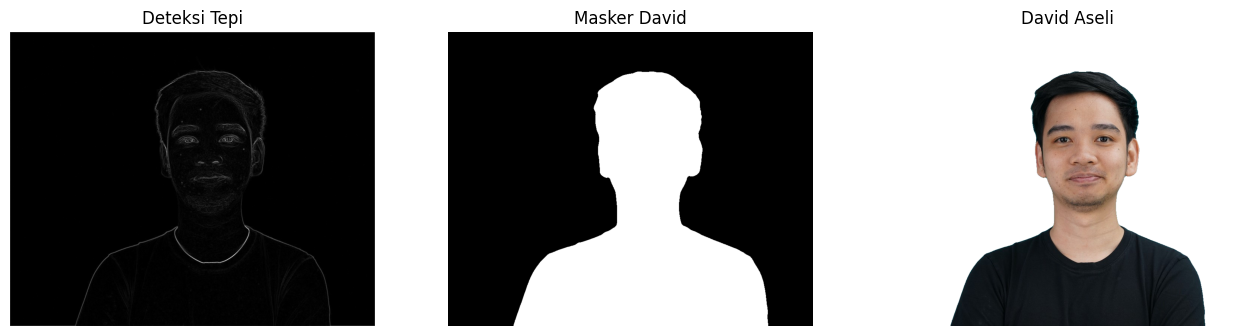

In [61]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(davidTepi, cmap = 'gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(DavidMask, cmap = 'gray')
plt.title('Masker David')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(davidNoBG)
plt.title('David Aseli')
plt.axis('off')

## Kesimpulan

Perbaikan kualitas citra dan deteksi tepi merupakan dua tahapan yang saling berkaitan dan sangat penting dalam pengolahan citra digital. Proses perbaikan kualitas citra melalui filter **smoothing** dan **sharpening** terbukti berperan besar dalam mempersiapkan gambar sebelum deteksi tepi dilakukan, di mana smoothing menekan noise yang dapat mengganggu hasil deteksi, sementara sharpening mempertegas detail objek agar tepi yang dihasilkan lebih akurat. Kombinasi keduanya secara bertahap menghasilkan kualitas gambar yang lebih optimal dibandingkan menggunakan salah satu metode saja.

Pada tahap deteksi tepi, pemilihan operator yang tepat sangat mempengaruhi kualitas hasil, di mana **Sobel** terbukti lebih unggul dalam ketahanan terhadap noise, **Prewitt** lebih konsisten pada berbagai arah tepi, dan **Roberts** lebih tajam namun sensitif terhadap noise. Kombinasi beberapa operator sekaligus menghasilkan deteksi tepi yang lebih menyeluruh karena saling melengkapi kelemahan masing-masing operator.

Selain itu, proses **thresholding** setelah deteksi tepi juga memegang peranan penting dalam menentukan kualitas akhir hasil segmentasi, di mana pemilihan nilai threshold yang tepat menjadi kunci keseimbangan antara kelengkapan tepi dan kebersihan dari noise. Secara keseluruhan, kombinasi perbaikan kualitas citra, deteksi tepi multi-operator, dan thresholding yang tepat merupakan pendekatan yang efektif untuk menghasilkan segmentasi objek yang akurat dan dapat diandalkan dalam berbagai aplikasi pengolahan citra digital seperti pengawasan CCTV, pengenalan objek, maupun analisis citra medis.